# Part 1

In [1]:
!which pip

/home/sai/.cache/uv/builds-v0/.tmpVOpUED/bin/pip


In [67]:
# Packages
import os
import glob
import cv2 as cv
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
import numpy as np
from PIL import Image

In [82]:
# Load the datasets

# change path according to where u put the folder
path = "flowers_dataset"
images_path = glob.glob(os.path.join(path, "*.jpg"))
assert len(images_path) != 0, "Check folder path, no image in path"
# if images_path.len == 0
print("Number of images:", len(images_path))


Number of images: 10


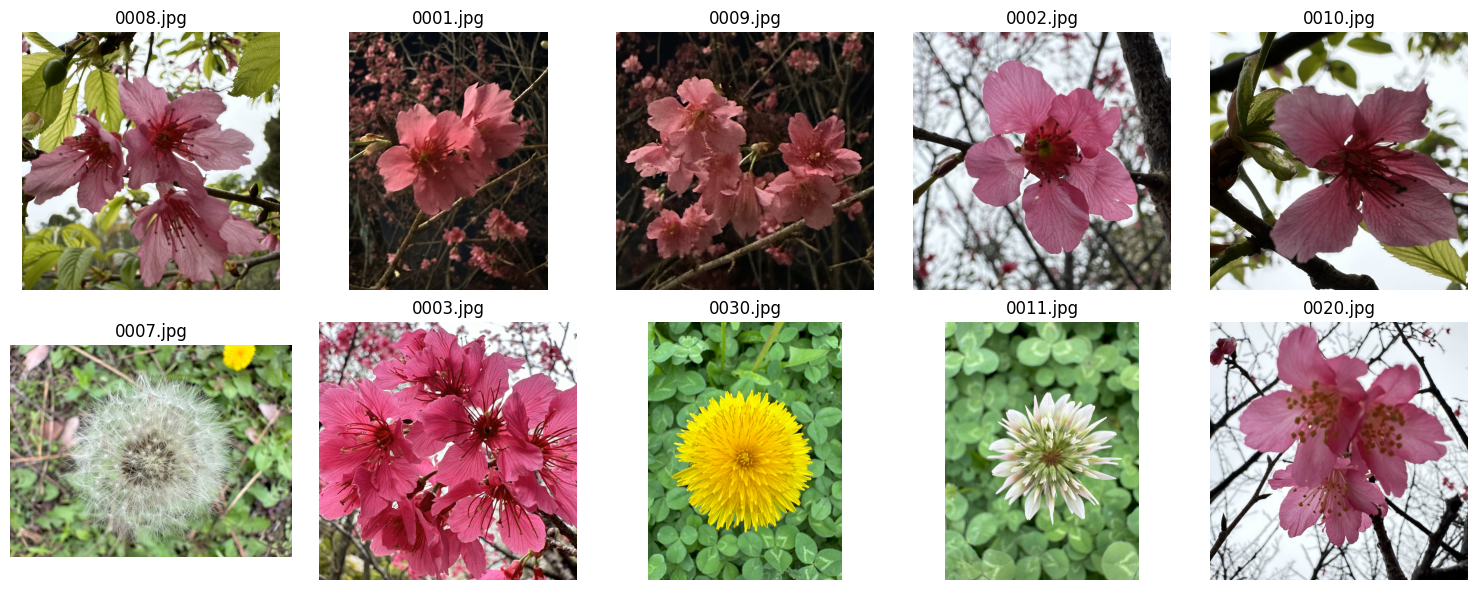

In [83]:
# Show all images first

plt.figure(figsize=(15, 6)) 

for i, file in enumerate(images_path):
    img = Image.open(file)
    plt.subplot(2, 5, i+1)  
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(file))

plt.tight_layout()
plt.show()

In [84]:
# Open them as PIL images
images = [Image.open(file) for file in images_path]

In [91]:
# Function that reshapes the images to (100,100,3)
def image_reshape(img):
    img = img.convert("RGB")
    img = img.resize((100, 100))
    return np.array(img)

In [95]:
# Reshape all
reshaped_img = [image_reshape(img) for img in images]

print("Shape of first reshaped image:", reshaped_img[0].shape)

Shape of first reshaped image: (100, 100, 3)


In [113]:
# Save all of the images in another directory

output_path = "reshaped_dataset"
os.makedirs(output_path, exist_ok=True)

for i, arr in enumerate(reshaped_img):
    img = Image.fromarray(arr)  # convert NumPy array back to PIL
    save_path = os.path.join(output_path, f"{i:03d}.jpg")
    img.save(save_path, "JPEG")

print(f"Saved {len(reshaped_img)} images to '{output_path}'")

Saved 10 images to 'reshaped_dataset'


In [97]:
# Separate RGB channels

img_data = np.stack(reshaped_img)

red = img_data[:,:,:,0].ravel()
green = img_data[:,:,:,1].ravel()
blue = img_data[:,:,:,2].ravel()

In [98]:
# Normalize img_data
rgb_norm = img_data / 255.0
hsv = rgb2hsv(rgb_norm)

In [99]:
# Separate hues, saturation, and intensities

hues        = hsv[:,:,:,0].ravel()       
saturations = hsv[:,:,:,1].ravel()        
intensities = hsv[:,:,:,2].ravel()

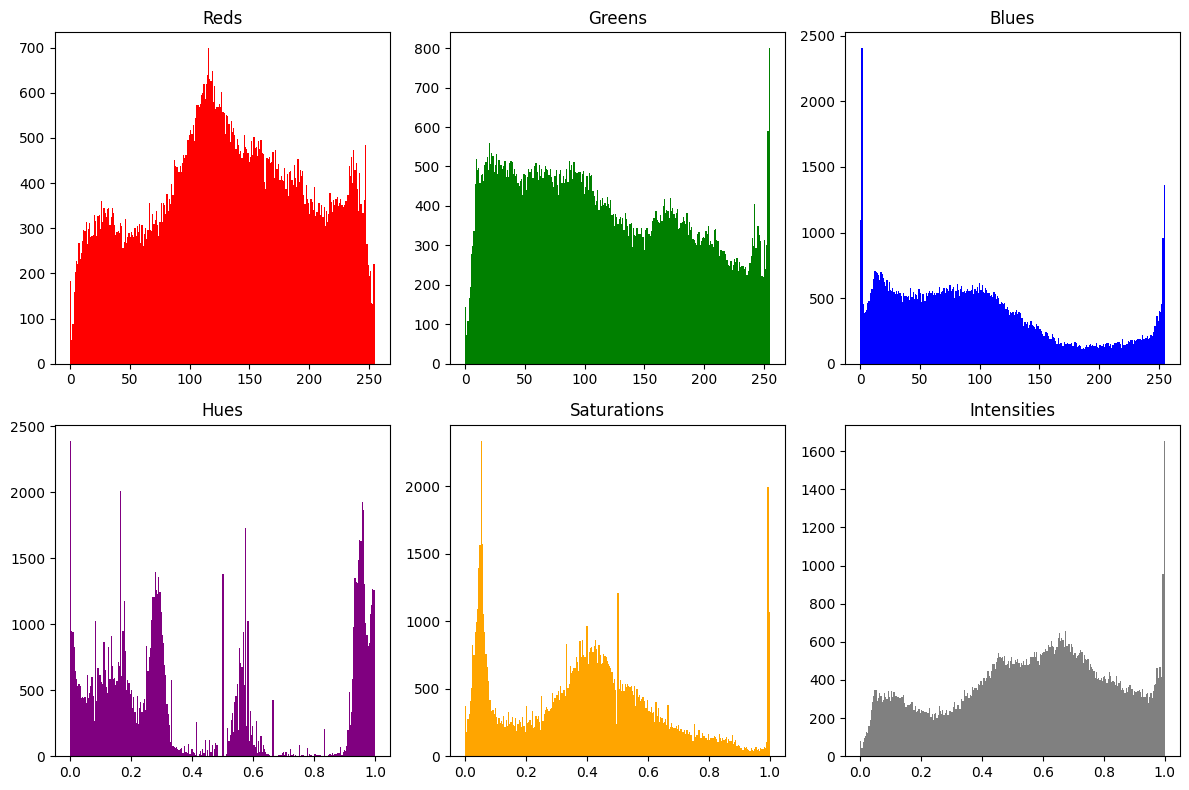

In [100]:
#Plot the histogram

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.hist(red, bins=256, color='red')
plt.title("Reds")

plt.subplot(2,3,2)
plt.hist(green, bins=256, color='green')
plt.title("Greens")

plt.subplot(2,3,3)
plt.hist(blue, bins=256, color='blue')
plt.title("Blues")

plt.subplot(2,3,4)
plt.hist(hues, bins=256, color='purple')
plt.title("Hues")

plt.subplot(2,3,5)
plt.hist(saturations, bins=256, color='orange')
plt.title("Saturations")

plt.subplot(2,3,6)
plt.hist(intensities, bins=256, color='gray')
plt.title("Intensities")

plt.tight_layout()
plt.show()


# [Data Cleaning] Develop a function that attains the following activities:

- Remove all images that are taken during the night.
- Remove all images that are not pink flowers.

In [101]:
# Function that detects if night time
# Returns images took during day or noon
def removeNight(imgs):
    day_images = []
    for img in imgs:
        hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
        brightness = hsv[:, :, 2].mean()
        if brightness > 80:         # Threshold value of 80 change if need.
            day_images.append(img)
    return day_images 

# 70 was the initial threshold value taken from the Medium article.
# It was then adjusted based on the observed brightness of the images identified
# taken during the night, thus 80 was selected.
    
# https://medium.com/@DIYCoding/classifying-day-evening-and-night-from-videos-using-opencv-5789f7f41956    


# Function that removes non pink flowers
# Returns images that are pink
def removeNonPink(imgs):
    pink_imgs = []

    for img in imgs:
        # Since most of the flowers in the data set are centered
        # set a focus region of 50px in the center
        foc = img[25:75, 20:75]
        hsv = cv.cvtColor(foc, cv.COLOR_BGR2HSV)

        # Define pink range in HSV (tweak if needed)
        # Range identified based on HSV color spectrum
        lower_pink = np.array([100, 50, 50])
        upper_pink = np.array([180, 255, 255])

        # Create mask
        mask = cv.inRange(hsv, lower_pink, upper_pink)

        # Count how many pixels are pink
        pink_pixels = cv.countNonZero(mask)
        total_pixels = foc.shape[0] * foc.shape[1]
        
        # Threshold (5% of image must be pink)
        if pink_pixels / total_pixels > 0.05:
            pink_imgs.append(img)
    return pink_imgs

In [102]:
cleaned_img = removeNight(reshaped_img)
cleaned_img = removeNonPink(cleaned_img)

# Maybe at plot of cleaned img set for verification?

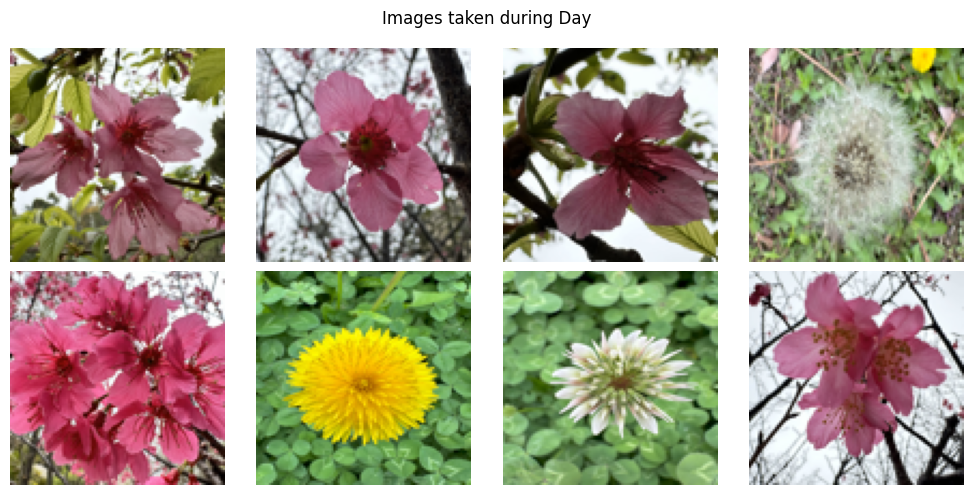

In [134]:
images_taken_day = removeNight(reshaped_img)
plt.figure(figsize=(10, 5)) 

for i,item in enumerate(images_taken_day):
    plt.subplot(2,4,i+1)
    plt.imshow(item)
    plt.axis("off")

plt.suptitle("Images taken during Day")
plt.tight_layout()
plt.show()

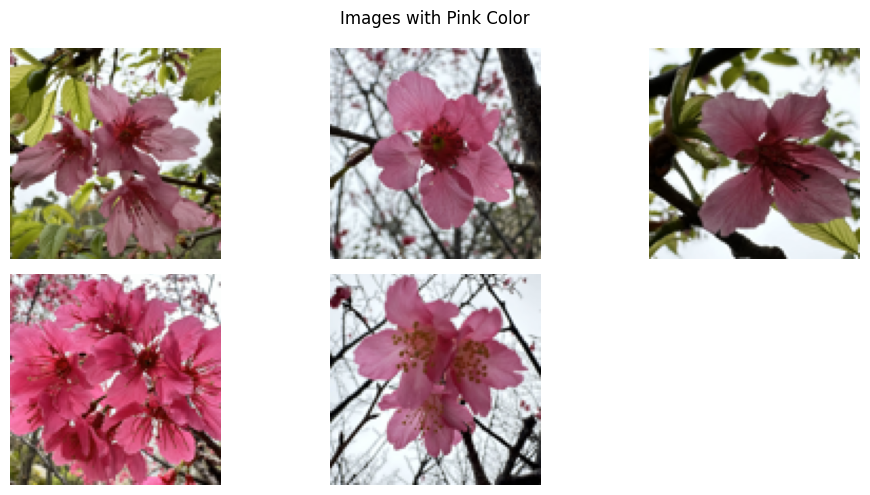

In [135]:
images_pink = removeNonPink(images_taken_day)
plt.figure(figsize=(10, 5)) 

for i,item in enumerate(images_pink):
    plt.subplot(2,3,i+1)
    plt.imshow(item)
    plt.axis("off")

plt.suptitle("Images with Pink Color")
plt.tight_layout()
plt.show()

Guide Questions:
+ What mathematical or statistical bases have you considered when developing your function?
    - For the Night detection function, the value or lightness of HSV values were used. The value is how light or dark the image is, typically if there is low lighting it would indicate the image was taked during night or in a dark space.
    - For the Pink detection function,
+ What are the challenges in re-orienting the images in this action item?
What can you suggest for automating such a task?

# Part 3

- Adjusts the exposure of the images based on the brightest image. (Hint: You may manually select the representative image and apply Gamma Correction)
- Adjusts the saturation of the images to match the saturation of the most saturated image. (Hint: You may manually select the representative image and apply Histogram Equalization and Channel Arithmetic)

In [120]:
new_dir = './data_enchancement/'
if not os.path.isdir(new_dir):
    print('creating new dir')
    os.mkdir(new_dir)

In [149]:
def plot_imgs(imgs: list, n_row, n_col, file_name=''):
    plt.close('all')  # Close any existing figures FIRST
    
    _, axs = plt.subplots(n_row, n_col, figsize=(10, 5))
    axs = axs.flatten()
    
    for img, ax in zip(imgs, axs):
        ax.imshow(img, cmap='gray')
        ax.axis('off')  # Optional: hide axes for cleaner look
    
    # Hide unused subplots
    for ax in axs[len(imgs):]:
        ax.axis('off')
    
    plt.tight_layout()
    if file_name.strip() != '': 
        plt.savefig(f'{file_name}.png', bbox_inches='tight')
    plt.show()
    plt.close('all')

In [150]:
def adjust_gamma(image, gamma=1.0):
    invGamma = 1.0 / (gamma+1e-06)
    table = np.array([((i / 255.0) ** invGamma) * 255
        for i in np.arange(0, 256)]).astype("uint8")
    return cv.LUT(image, table)

In [151]:
def adjust_saturation(image, ref_sat):
    
    hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)
    
    # Equalize only the S channel
    s_eq = cv.equalizeHist(s)
    
    merged = cv.merge([h, s_eq, v])
    eq_img = cv.cvtColor(merged, cv.COLOR_HSV2BGR)
    
    hsv_target = cv.cvtColor(eq_img, cv.COLOR_BGR2HSV)
    target_avg_sat = np.mean(hsv_target[:, :, 1])
    
    # Scale saturation to match reference
    scale = ref_sat / target_avg_sat
    h, s, v = cv.split(hsv_target)
    s_adjusted = np.clip(s * scale, 0, 255).astype(np.uint8)
    
    merged = cv.merge([h, s_adjusted, v])
    res = cv.cvtColor(merged, cv.COLOR_HSV2BGR)
    return res

In [152]:
# https://www.geeksforgeeks.org/python/how-to-iterate-over-files-in-directory-using-python/

directory = 'reshaped_dataset'
WIDTH = 100
HEIGHT = 100
# if not os.path.isdir(new_dir):
#     print('creating new dir')
#     os.mkdir(new_dir)

# Determine maximum luminance and saturation of an image
ref_y = 0 # maximum avg luminance
ref_s = 0 # maximum avg saturation
for entry in os.scandir(directory):
    if entry.is_file():
        print(entry.path)
        img = cv.imread(entry.path)
        img_ycrcb = cv.cvtColor(img, cv.COLOR_BGR2YCrCb)
        img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
        img_y = cv.split(img_ycrcb)[0] # gets luminance from image
        img_s = cv.split(img_hsv)[1]   # gets saturation
        ref_y = max(ref_y, np.mean(img_y)) #average y or luminance
        ref_s = max(ref_s, np.mean(img_s))
        print(f'max_y: {max_y} | max_s: {max_s}')
        # h,s,v = img_hsv
        # print(img_ycrcb)

reshaped_dataset/003.jpg
max_y: 154.6183 | max_s: 163.7207
reshaped_dataset/004.jpg
max_y: 154.6183 | max_s: 163.7207
reshaped_dataset/000.jpg
max_y: 154.6183 | max_s: 163.7207
reshaped_dataset/005.jpg
max_y: 154.6183 | max_s: 163.7207
reshaped_dataset/007.jpg
max_y: 154.6183 | max_s: 163.7207
reshaped_dataset/002.jpg
max_y: 154.6183 | max_s: 163.7207
reshaped_dataset/001.jpg
max_y: 154.6183 | max_s: 163.7207
reshaped_dataset/009.jpg
max_y: 154.6183 | max_s: 163.7207
reshaped_dataset/008.jpg
max_y: 154.6183 | max_s: 163.7207
reshaped_dataset/006.jpg
max_y: 154.6183 | max_s: 163.7207


In [160]:
# Manipulate gamma and saturation
# write_dir = "./data_enchancement/"
# i = 0
gamma_corrected = []
saturation_corrected = []
imgs = []
for entry in os.scandir(directory):
    if entry.is_file():
        print(entry.path)
        
        img = cv.imread(entry.path)
        img_ycrcb = cv.cvtColor(img, cv.COLOR_BGR2YCrCb)
        avg_y = np.mean(cv.split(img_ycrcb)[0]) # gets luminance from image
        gamma_scale = ref_y / avg_y
        sat_scale = ref_s / avg_s
        gamma_adj_img = adjust_gamma(img, gamma_scale)
        sat_adj_img = adjust_saturation(img, ref_s)
        # convert to rgb then add to list
        imgs.append(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        gamma_corrected.append(cv.cvtColor(gamma_adj_img, cv.COLOR_BGR2RGB))
        saturation_corrected.append(cv.cvtColor(sat_adj_img, cv.COLOR_BGR2RGB))
        # cv.imwrite(f'{write_dir}gamma{i:03d}.jpg', gamma_adj_img)
        # cv.imwrite(f'{write_dir}sat{i:03d}.jpg', sat_adj_img)
        # i += 1
        # h,s,v = img_hsv
        # print(img_ycrcb)

reshaped_dataset/003.jpg
reshaped_dataset/004.jpg
reshaped_dataset/000.jpg
reshaped_dataset/005.jpg
reshaped_dataset/007.jpg
reshaped_dataset/002.jpg
reshaped_dataset/001.jpg
reshaped_dataset/009.jpg
reshaped_dataset/008.jpg
reshaped_dataset/006.jpg


## Gamma corrected

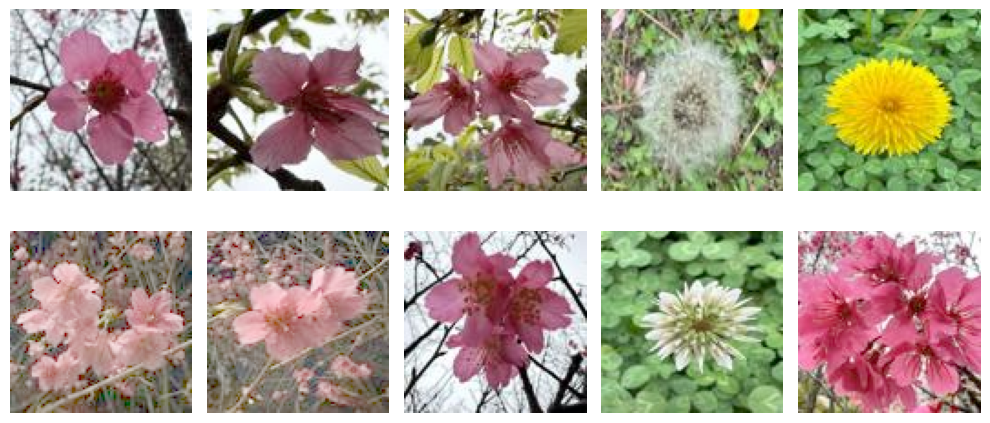

In [161]:
plot_imgs(gamma_corrected, 2, 5)

## Saturation corrected

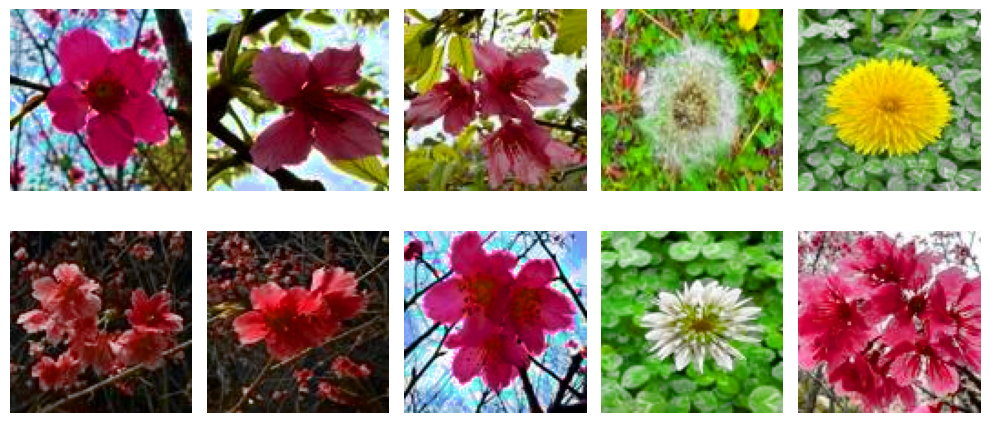

In [162]:
plot_imgs(saturation_corrected, 2, 5)

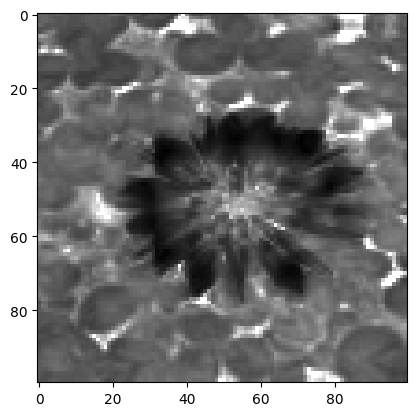

avg: 140.5541


In [64]:
# test =  [[ 53,  86, 154],
#         [ 53,  79, 167],
#         [ 53,  76, 177],
#         [ 53,  75, 177],
#         [ 53,  75, 176],
#         [ 53,  71, 188]]
# test_np = np.array(test)
test_avg = np.average(img_ycrcb, axis=0)
ycrcb_planes = cv.split(img_ycrcb)
plt.imshow(img_s, cmap='gray')
plt.show()
# print(f'avg: {test_avg}, \n shape: {img_ycrcb.shape}')
type(test_np)
print(f'avg: {np.mean(ycrcb_planes[0])}')

# Part 4

In [78]:
new_dir = './augmented_imgs'
if not os.path.isdir(new_dir):
    print('creating new dir')
    os.mkdir(new_dir)

creating new dir


## Apply Black Patch

In [ ]:
# not sure what exactly this is supposed to do?
# probly just apply cv.rectangle on the portions of an image,
# cv.rectangle(img, (x, y), (x+w, y+h), (255, 255, 255), 5)
def black_patch(img, x: int, y:int, w: int, h: int):
    res = cv.rectangle(img, (x,y), (x+w,y+h), (0,0,0), -1)
    return res

## Shifting

In [ ]:
def shift_img(img, x: int, y: int):
    rows,cols,_ = img.shape
    M = np.float32([[1,0,x], [0,1,y]])
    dst = cv.warpAffine(img, M, (cols, rows))
    return dst

## Rotation 

In [ ]:
def rotate_img(img, degrees):
    # in this activity degrees is only limited to 30 or 60 degrees
    # but this function can accept 0~360
    rows,cols,_ = img.shape
    M = cv.getRotationMatrix2D(((cols-1) / 2.0, (rows-1)/ 2.0), 90, 1)
    dst = cv.warpAffine(img, M, (cols, rows))
    return dst

## Flip

In [ ]:
def flip_img(img, orientation='h'):
    # https://pyimagesearch.com/2021/01/20/opencv-flip-image-cv2-flip/
    # flip code 1 for horizontal, 0 for vertical
    match orientation:
        case 'h':
            #flip horizontally
            dst = cv.flip(img, 1)
        case 'v':
            #flip vertically   
            dst = cv.flip(img, 0)
        case _:
            dst = img 
            print('Error, invalid orientation input returning input image')
    return dst

## Saturation

In [106]:
def saturation_equalization(img):
    # changes image saturation via Histogram Equalization
    # https://www.delftstack.com/howto/python/opencv-histogram-equalization/
    # Multichannel histogram equalization
    img = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(img)
    s_eq = cv.equalizeHist(s)

    eq_img = cv.merge((h, s, v))
    return eq_img

In [ ]:
## Main exec
WIDTH = 100
HEIGHT = 100

fname_ctr = 0 # reset this after it reaches 9
i = 10 # assume first 10 is data formatted images

bp_xlimit = WIDTH
bp_ylimit = HEIGHT
bp_wlimit = WIDTH // 4
bp_hlimit = HEIGHT // 4

TOTAL_IMGS = 100           
IMG_FUNC = TOTAL_IMGS // 5 # images per function

# Black Patch call
for n in range(IMG_FUNC):
    if fname_ctr >= 10:
        fname_ctr = 0
    curr_img = cv.imread(f'./img_formatted/{fname_ctr: 04d}.jpg')
    bp_x = random.randint(0, bp_xlimit - bp_wlimit - 10)  # ensure enough room for patch width
    bp_y = random.randint(0, bp_ylimit - bp_hlimit - 10)  # ensure enough room for patch height
    bp_w = random.randint(10, bp_wlimit)
    bp_h = random.randint(10, bp_hlimit)
    res = black_patch(curr_img, bp_x, bp_y, bp_w, bp_h)
    cv.imwrite(f'./img_formatted/{i: 04d}.jpg', res)
    fname_ctr += 1
    i += 1

# shift_img call
shift_xlimit = WIDTH // 3 # limit the amount of shifting to 1/3 of the image
shift_ylimit = HEIGHT // 3
for n in range(IMG_FUNC):
    if fname_ctr >= 10:
        fname_ctr = 0
    # print(f'{fname_ctr: 04d}.jpg')
    curr_img = cv.imread(f'./img_formatted/{fname_ctr: 04d}.jpg')
    shiftx = random.randint(-shift_xlimit, shift_xlimit)  # rng value for sideward shifting 
    shifty = random.randint(-shift_ylimit, 0) # rng value for upward shifting
    res = shift_img(curr_img, shiftx, shifty)
    cv.imwrite(f'./img_formatted/{i: 04d}.jpg', res)
    fname_ctr += 1
    i += 1

# rotation call
for n in range(IMG_FUNC):
    if fname_ctr >= 10:
        fname_ctr = 0
    angle = random.choice([30, 60])
    curr_img = cv.imread(f'./img_formatted/{fname_ctr: 04d}.jpg')
    res = rotate_img(curr_img, angle)
    cv.imwrite(f'./img_formatted/{i: 04d}.jpg', res)
    fname_ctr += 1
    i += 1

# flip call    
for n in range(IMG_FUNC):
    if fname_ctr >= 10:
        fname_ctr = 0
    flip_dir = random.choice(['h', 'v'])
    curr_img = cv.imread(f'./img_formatted/{fname_ctr: 04d}.jpg')
    res = flip_img(curr_img, flip_dir)
    cv.imwrite(f'./img_formatted/{i: 04d}.jpg', res)
    fname_ctr += 1
    i += 1

# Saturation Call
for n in range(IMG_FUNC):
    if fname_ctr >= 10:
        fname_ctr = 0
    curr_img = cv.imread(f'./img_formatted/{fname_ctr: 04d}.jpg')
    res = flip_img(curr_img, flip_dir)
    cv.imwrite(f'./img_formatted/{i: 04d}.jpg', res)
    fname_ctr += 1
    i += 1

